In [ ]:
# =============================================
# CELL 1: Install Library
# =============================================
!pip install ultralytics -qb


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -b


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics versi: 8.4.26
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Isi folder dataset:
  - README.dataset.txt
  - README.roboflow.txt
  - data.yaml
  - runs
  - train
  - valid
PyTorch version : 2.10.0+cu128
GPU Available   : True
GPU Name        : Tesla T4
GPU Memory      : 15.6 GB
data.yaml ASLI:
  train : ../train/images
  val   : ../valid/images
  nc    : 6
  names : ['kepala_miring', 'kepala_tegak', 'mata_close', 'mata_open', 'mulut_close', 'mulut_open']

Folder gambar yang ditemukan:
  [ 1755 gambar] /content/drive/MyDrive/YoloV8/train/images
  [  752 gambar] /content/drive/MyDrive/Yolo

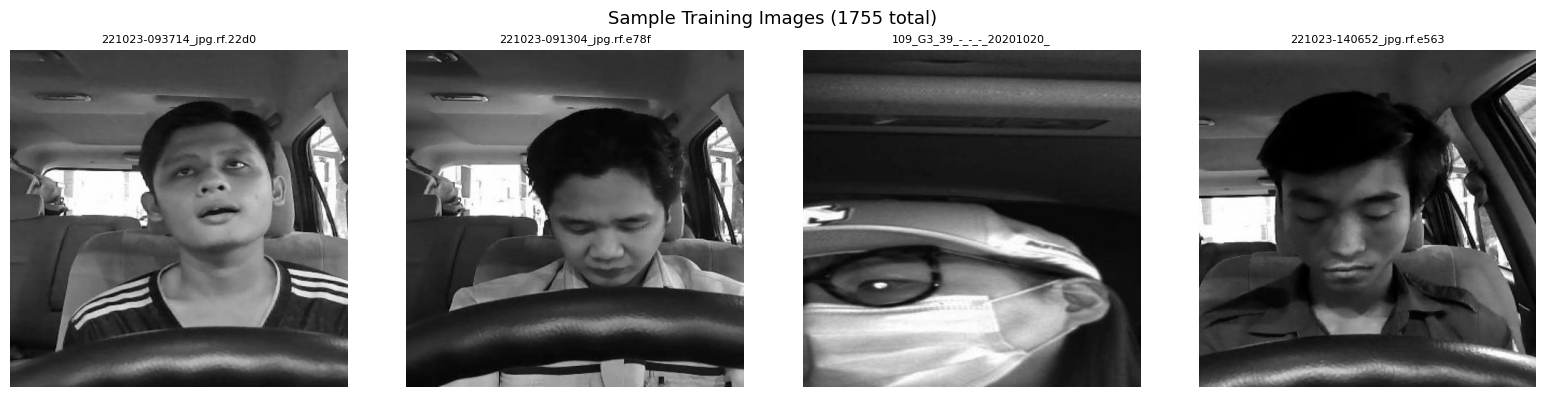

Memulai training YOLOv8...
  Model  : yolov8n.pt
  Epochs : 25
  Batch  : 16
  Device : GPU (Tesla T4)
-------------------------------------------------------
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_kantuk_fixed.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, mome

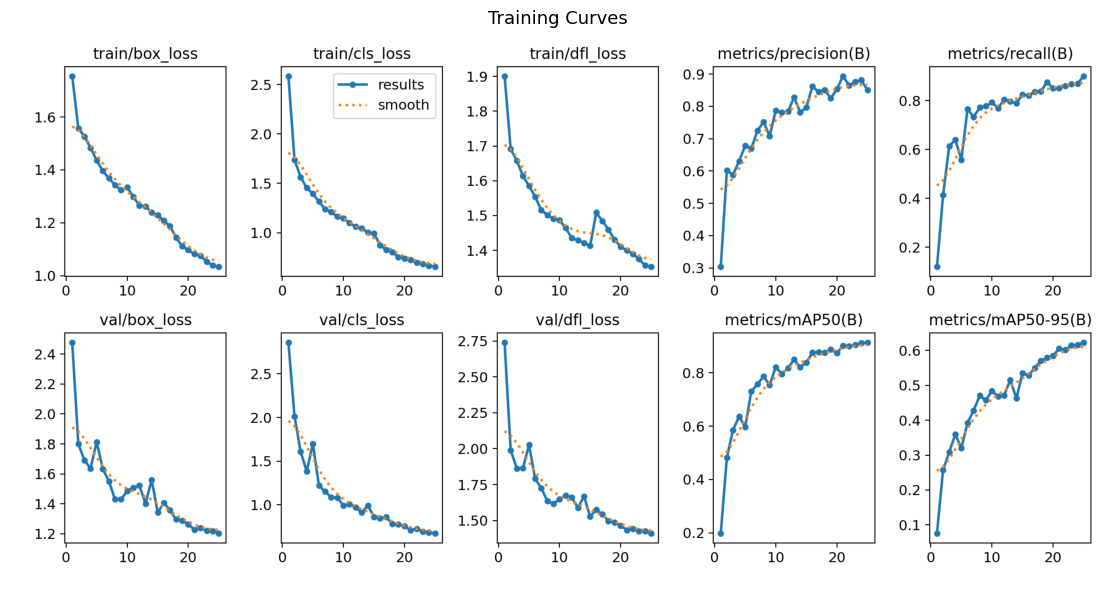

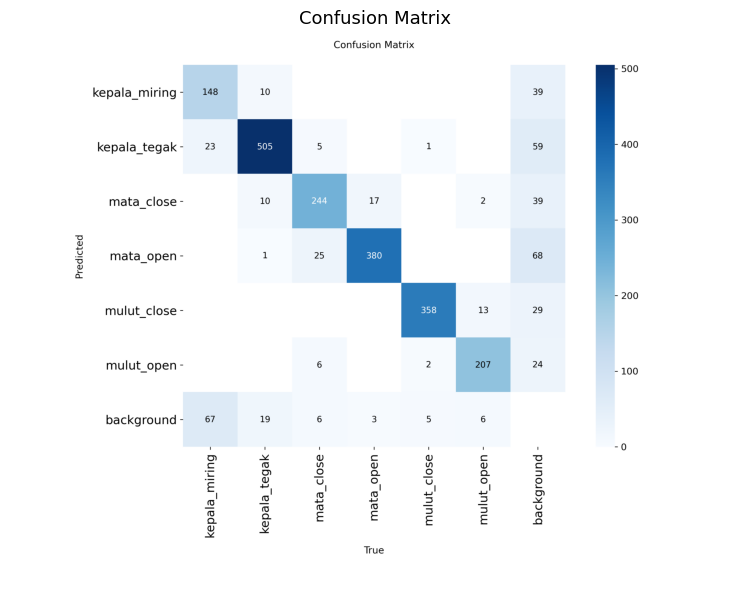

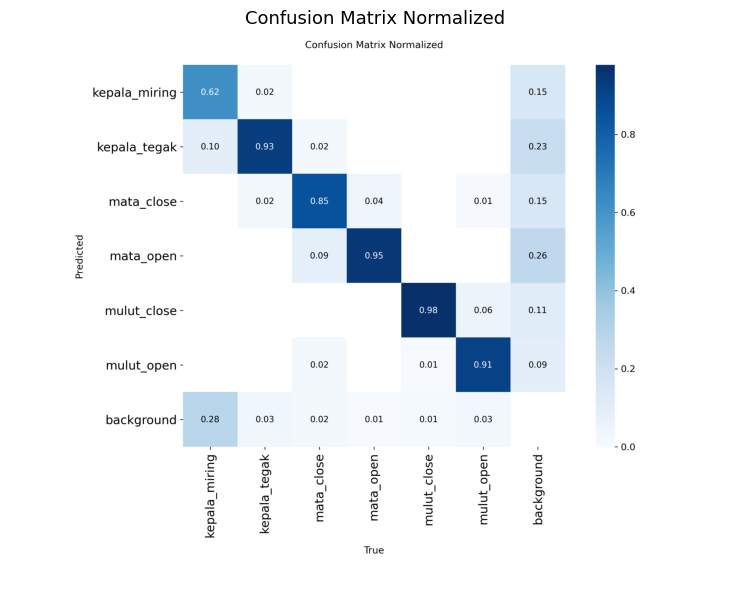

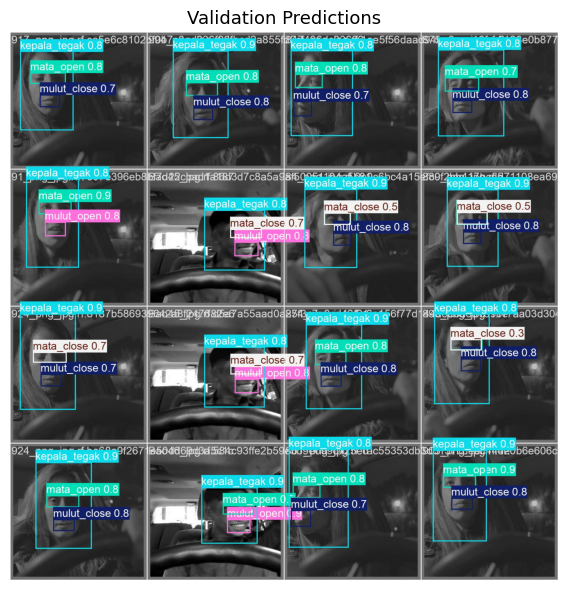

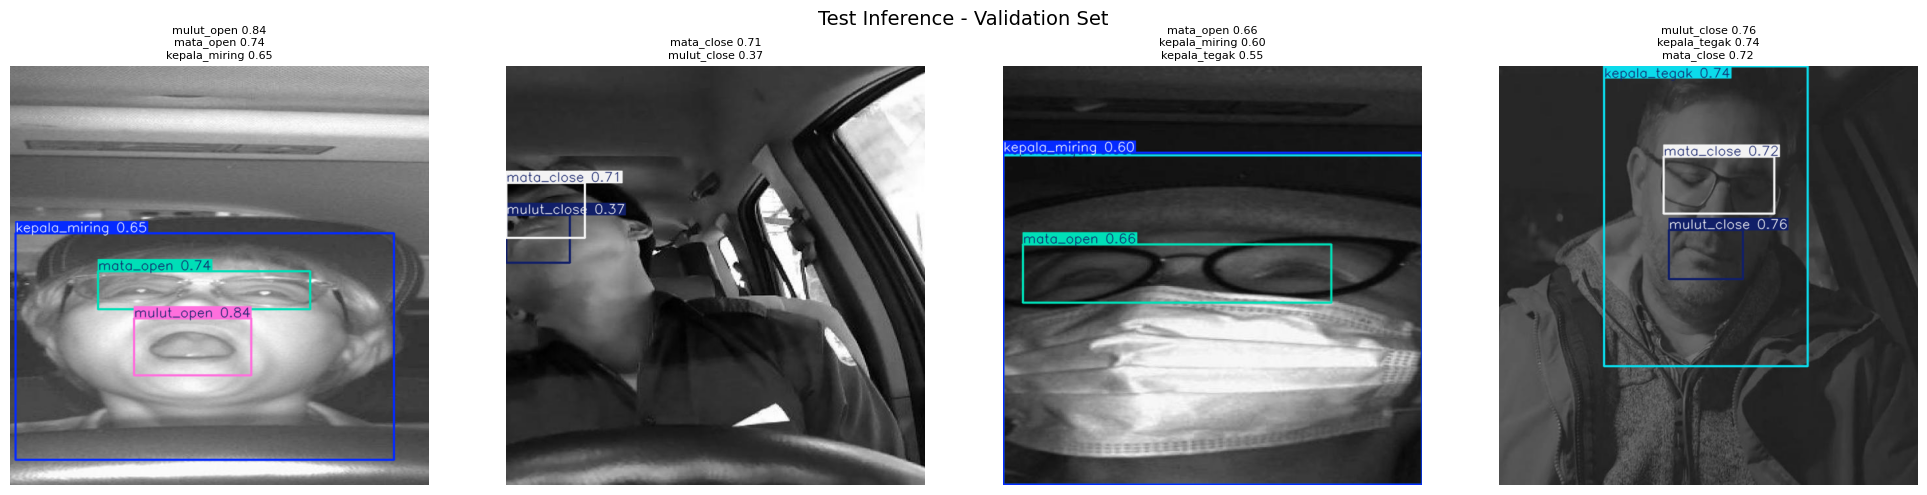

Exporting ONNX... Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 255ms
Prepared 3 packages in 7.63s
Installed 3 packages in 13ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 8.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: s

In [ ]:
# ============================================================
# CELL 1: Install Dependencies  ← JALANKAN INI DULU!
# ============================================================
!pip install ultralytics -q
!pip install onnx onnxsim -q

# Verifikasi
import ultralytics
print(f"✅ Ultralytics versi: {ultralytics.__version__}")


# ============================================================
# CELL 2: Mount Google Drive & Cek Folder
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_PATH = "/content/drive/MyDrive/YoloV8"

print("Isi folder dataset:")
for item in sorted(os.listdir(DATASET_PATH)):
    print(f"  - {item}")


# ============================================================
# CELL 3: Import Library & Cek GPU
# ============================================================
import os
import yaml
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from glob import glob
from ultralytics import YOLO

print("=" * 55)
print(f"PyTorch version : {torch.__version__}")
print(f"GPU Available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Tidak ada GPU!")
    print("   Aktifkan di: Runtime → Change runtime type → T4 GPU")
print("=" * 55)


# ============================================================
# CELL 4: AUTO-FIX PATH DATASET
# ============================================================
YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

with open(YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

print("data.yaml ASLI:")
print(f"  train : {data_config.get('train')}")
print(f"  val   : {data_config.get('val')}")
print(f"  nc    : {data_config.get('nc')}")
print(f"  names : {data_config.get('names')}")

# Cari semua folder berisi gambar
def find_image_dirs(base_path):
    found = []
    for root, dirs, files in os.walk(base_path):
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
        if imgs:
            found.append((root, len(imgs)))
    return sorted(found, key=lambda x: x[1], reverse=True)

img_dirs = find_image_dirs(DATASET_PATH)
print(f"\nFolder gambar yang ditemukan:")
for d, count in img_dirs:
    print(f"  [{count:5d} gambar] {d}")

def pick_dir(candidates, keyword):
    matches = [(d, c) for d, c in candidates if keyword in d.lower()]
    return matches[0][0] if matches else None

train_path = pick_dir(img_dirs, 'train')
valid_path = pick_dir(img_dirs, 'val') or pick_dir(img_dirs, 'valid')

assert train_path, "❌ Folder train tidak ditemukan!"
assert valid_path, "❌ Folder valid/val tidak ditemukan!"

print(f"\nPath yang akan digunakan:")
print(f"  train : {train_path}")
print(f"  val   : {valid_path}")

# Verifikasi sample gambar bisa dibaca
sample_files = glob(os.path.join(train_path, '*.jpg'))[:2] + \
               glob(os.path.join(train_path, '*.png'))[:2]
print(f"\nVerifikasi sample gambar:")
for img_path in sample_files[:3]:
    fb  = np.fromfile(img_path, np.uint8)
    img = cv2.imdecode(fb, cv2.IMREAD_COLOR)
    status = f"✅ shape: {img.shape}" if img is not None else "❌ CORRUPT"
    print(f"  {status} — {os.path.basename(img_path)}")

# Update & simpan YAML baru
data_config['train'] = train_path
data_config['val']   = valid_path
if 'test' in data_config:
    del data_config['test']

UPDATED_YAML = '/content/data_kantuk_fixed.yaml'
with open(UPDATED_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f"\n✅ YAML fixed disimpan: {UPDATED_YAML}")
print("\nISI YAML BARU:")
with open(UPDATED_YAML) as f:
    print(f.read())


# ============================================================
# CELL 5: Preview Sample Gambar
# ============================================================
all_train = (glob(os.path.join(train_path, '*.jpg')) +
             glob(os.path.join(train_path, '*.jpeg')) +
             glob(os.path.join(train_path, '*.png')))
all_val   = (glob(os.path.join(valid_path, '*.jpg')) +
             glob(os.path.join(valid_path, '*.jpeg')) +
             glob(os.path.join(valid_path, '*.png')))

print(f"Total gambar train : {len(all_train)}")
print(f"Total gambar val   : {len(all_val)}")

sample_show = all_train[:4]
fig, axes = plt.subplots(1, len(sample_show), figsize=(16, 4))
fig.suptitle(f"Sample Training Images ({len(all_train)} total)", fontsize=13)
if len(sample_show) == 1:
    axes = [axes]
for ax, img_path in zip(axes, sample_show):
    fb  = np.fromfile(img_path, np.uint8)
    img = cv2.imdecode(fb, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)[:25], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


# ============================================================
# CELL 6: TRAINING YOLOV8
# ============================================================

# n=nano (RPi/Jetson), s=small (laptop CPU), m=medium (GPU)
MODEL_SIZE = 'yolov8n.pt'

model = YOLO(MODEL_SIZE)

TRAINING_CONFIG = {
    'data'          : UPDATED_YAML,
    'epochs'        : 25,
    'imgsz'         : 640,
    'batch'         : 16,       # OOM? coba 8 atau 4
    'patience'      : 20,
    'device'        : 0 if torch.cuda.is_available() else 'cpu',
    'workers'       : 2,
    'project'       : '/content/drive/MyDrive/YoloV8/runs',
    'name'          : 'deteksi_kantuk_v1',
    'exist_ok'      : True,
    'save'          : True,
    'save_period'   : 10,
    'plots'         : True,

    # Augmentasi
    'flipud'        : 0.0,
    'fliplr'        : 0.5,
    'mosaic'        : 1.0,
    'degrees'       : 10.0,
    'translate'     : 0.1,
    'scale'         : 0.5,
    'shear'         : 2.0,
    'hsv_h'         : 0.015,
    'hsv_s'         : 0.7,
    'hsv_v'         : 0.4,

    # Optimizer
    'optimizer'     : 'AdamW',
    'lr0'           : 0.001,
    'lrf'           : 0.01,
    'momentum'      : 0.937,
    'weight_decay'  : 0.0005,
    'warmup_epochs' : 3,

    'conf'          : 0.25,
    'iou'           : 0.45,
    'verbose'       : True,
}

print("Memulai training YOLOv8...")
print(f"  Model  : {MODEL_SIZE}")
print(f"  Epochs : {TRAINING_CONFIG['epochs']}")
print(f"  Batch  : {TRAINING_CONFIG['batch']}")
print(f"  Device : {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")
print("-" * 55)

results = model.train(**TRAINING_CONFIG)
print("\n✅ Training selesai!")


# ============================================================
# CELL 7: Evaluasi
# ============================================================
RESULTS_DIR     = "/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1"
BEST_MODEL_PATH = os.path.join(RESULTS_DIR, "weights", "best.pt")

if not os.path.exists(BEST_MODEL_PATH):
    BEST_MODEL_PATH = os.path.join(RESULTS_DIR, "weights", "last.pt")
    print("⚠️  Pakai last.pt")

model_eval = YOLO(BEST_MODEL_PATH)
metrics    = model_eval.val(data=UPDATED_YAML, conf=0.25, verbose=False)

print("\n📊 Hasil Evaluasi:")
print(f"  mAP50    : {metrics.box.map50:.4f}")
print(f"  mAP50-95 : {metrics.box.map:.4f}")

names = data_config.get('names', {})
print("\n  Per-class mAP50:")
for i, ap in enumerate(metrics.box.maps):
    cls_name = names.get(i, f'class_{i}') if isinstance(names, dict) else names[i]
    print(f"    [{i}] {cls_name:20s}: {ap:.4f}")


# ============================================================
# CELL 8: Plot Training
# ============================================================
for filename, title in [
    ('results.png',                       'Training Curves'),
    ('confusion_matrix.png',              'Confusion Matrix'),
    ('confusion_matrix_normalized.png',   'Confusion Matrix Normalized'),
    ('val_batch0_pred.jpg',               'Validation Predictions'),
    ('PR_curve.png',                      'Precision-Recall Curve'),
    ('F1_curve.png',                      'F1 Curve'),
]:
    fpath = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(fpath):
        img = mpimg.imread(fpath)
        plt.figure(figsize=(12, 6))
        plt.imshow(img)
        plt.title(title, fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


# ============================================================
# CELL 9: Test Inference
# ============================================================
test_images = all_val[:4]

preds = model_eval.predict(source=test_images, conf=0.35, iou=0.45,
                            save=False, verbose=False)

n = len(preds)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
fig.suptitle("Test Inference - Validation Set", fontsize=14)
if n == 1:
    axes = [axes]

for result, ax in zip(preds, axes):
    img_plot = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_plot)
    boxes = result.boxes
    if boxes is not None and len(boxes):
        labels = [result.names[int(c)] for c in boxes.cls]
        confs  = [f"{float(c):.2f}" for c in boxes.conf]
        ax.set_title('\n'.join(f"{l} {c}" for l, c in zip(labels, confs)), fontsize=8)
    else:
        ax.set_title("No detection", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# CELL 10: Export Model ke Semua Format
# ============================================================
model_best    = YOLO(BEST_MODEL_PATH)
export_results = {}

for fmt, kwargs, label in [
    ('onnx',        dict(opset=12, simplify=True, dynamic=False), 'ONNX'),
    ('openvino',    dict(half=False),                              'OpenVINO'),
    ('tflite',      dict(half=False, int8=False),                  'TFLite'),
    ('torchscript', dict(),                                        'TorchScript'),
]:
    print(f"Exporting {label}...", end=' ')
    try:
        model_best.export(format=fmt, imgsz=640, **kwargs)
        export_results[label] = '✅'
        print("✅")
    except Exception as e:
        export_results[label] = '❌'
        print(f"❌ {e}")

# List semua file hasil
WEIGHTS_DIR = os.path.join(RESULTS_DIR, "weights")
print(f"\n📁 File model di {WEIGHTS_DIR}:")
for entry in sorted(os.scandir(WEIGHTS_DIR), key=lambda e: e.name):
    if entry.is_file():
        print(f"   {entry.name:45s} {entry.stat().st_size/1e6:6.1f} MB")
    elif entry.is_dir():
        sz = sum(f.stat().st_size for f in Path(entry.path).rglob('*') if f.is_file()) / 1e6
        print(f"   {entry.name+'/':45s} {sz:6.1f} MB  [folder]")

print("\n" + "=" * 55)
print("SUMMARY:")
target = {
    'ONNX'       : 'Laptop CPU / Mini PC / RPi',
    'OpenVINO'   : 'Intel NUC / Laptop Intel iGPU',
    'TFLite'     : 'Raspberry Pi 4/5',
    'TorchScript': 'Laptop/Desktop (backup)',
}
for fmt, status in export_results.items():
    print(f"  {status}  {fmt:15s} → {target.get(fmt,'-')}")

print("\n⚠️  TensorRT (Jetson): jalankan di Jetson langsung:")
print("   from ultralytics import YOLO")
print("   YOLO('best.pt').export(format='engine', half=True, device=0)")
print("\n✅ Semua selesai!")

In [ ]:
# =============================================
# YOLOV8 DETEKSI KANTUK - TRAINING (GOOGLE COLAB)
# Dataset: Roboflow - deteksi-kantuk-pada-pengemudi-v3
# =============================================

# =============================================
# CELL 1: Install Dependencies
# =============================================
# !pip install ultralytics roboflow -q

# =============================================
# CELL 2: Mount Google Drive
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_PATH = "/content/drive/MyDrive/YoloV8"
print("Isi folder dataset:")
for item in os.listdir(DATASET_PATH):
    print(" -", item)

# =============================================
# CELL 3: Import & Setup
# =============================================
import os
import yaml
import shutil
import torch
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Check GPU
print("=" * 50)
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("=" * 50)

# =============================================
# CELL 4: Verifikasi data.yaml
# =============================================
YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

with open(YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

print("Konfigurasi Dataset:")
print(f"  Classes   : {data_config.get('nc')} class")
print(f"  Names     : {data_config.get('names')}")
print(f"  Train path: {data_config.get('train')}")
print(f"  Val path  : {data_config.get('val')}")
print(f"  Test path : {data_config.get('test', 'N/A')}")

# Update path agar absolute (penting untuk Colab)
data_config['train'] = os.path.join(DATASET_PATH, 'train', 'images')
data_config['val']   = os.path.join(DATASET_PATH, 'valid', 'images')

# Simpan yaml yang sudah diupdate
UPDATED_YAML = '/content/data_kantuk.yaml'
with open(UPDATED_YAML, 'w') as f:
    yaml.dump(data_config, f)

print(f"\nYAML updated dan disimpan ke: {UPDATED_YAML}")

# =============================================
# CELL 5: Cek sampel gambar dataset
# =============================================
train_img_dir = os.path.join(DATASET_PATH, 'train', 'images')
train_imgs = os.listdir(train_img_dir)[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"Sample Training Images (total: {len(os.listdir(train_img_dir))} gambar)", fontsize=13)
for ax, img_name in zip(axes, train_imgs):
    img = mpimg.imread(os.path.join(train_img_dir, img_name))
    ax.imshow(img)
    ax.set_title(img_name[:20], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

# =============================================
# CELL 6: TRAINING YOLOV8
# =============================================

# Pilih model: yolov8n (nano) untuk edge device, yolov8s/m untuk laptop/desktop
MODEL_SIZE = 'yolov8n.pt'   # n=nano, s=small, m=medium, l=large, x=xlarge

# Load pretrained model
model = YOLO(MODEL_SIZE)

# Hyperparameter Training
TRAINING_CONFIG = {
    'data'       : UPDATED_YAML,
    'epochs'     : 50,
    'imgsz'      : 640,
    'batch'      : 16,          # Kurangi jika OOM: 8 atau 4
    'patience'   : 20,          # Early stopping
    'device'     : 0 if torch.cuda.is_available() else 'cpu',
    'workers'    : 4,
    'project'    : '/content/drive/MyDrive/YoloV8/runs',
    'name'       : 'deteksi_kantuk_v1',
    'exist_ok'   : True,

    # Augmentasi
    'flipud'     : 0.0,
    'fliplr'     : 0.5,
    'mosaic'     : 1.0,
    'degrees'    : 10.0,
    'translate'  : 0.1,
    'scale'      : 0.5,
    'shear'      : 2.0,
    'perspective': 0.0,
    'hsv_h'      : 0.015,
    'hsv_s'      : 0.7,
    'hsv_v'      : 0.4,

    # Hyperparameter optimizer
    'optimizer'  : 'AdamW',
    'lr0'        : 0.001,
    'lrf'        : 0.01,
    'momentum'   : 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,

    # Confidence & IoU threshold
    'conf'       : 0.25,
    'iou'        : 0.45,

    'save'       : True,
    'save_period': 10,
    'plots'      : True,
    'verbose'    : True,
}

print("Memulai training...")
print(f"Model  : {MODEL_SIZE}")
print(f"Epochs : {TRAINING_CONFIG['epochs']}")
print(f"Device : {'GPU' if torch.cuda.is_available() else 'CPU'}")
print("-" * 50)

results = model.train(**TRAINING_CONFIG)

print("\n✅ Training selesai!")
print(f"Model tersimpan di: {TRAINING_CONFIG['project']}/{TRAINING_CONFIG['name']}")

# =============================================
# CELL 7: Evaluasi hasil training
# =============================================
# Load model terbaik
BEST_MODEL_PATH = f"/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt"
model_eval = YOLO(BEST_MODEL_PATH)

# Validasi
metrics = model_eval.val(data=UPDATED_YAML, conf=0.25)

print("\n📊 Hasil Evaluasi:")
print(f"  mAP50     : {metrics.box.map50:.4f}")
print(f"  mAP50-95  : {metrics.box.map:.4f}")
print(f"  Precision  : {metrics.box.p[0]:.4f}")
print(f"  Recall     : {metrics.box.r[0]:.4f}")

# =============================================
# CELL 8: Tampilkan plot training
# =============================================
RESULTS_DIR = f"/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1"

plot_files = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']
for pf in plot_files:
    pf_path = os.path.join(RESULTS_DIR, pf)
    if os.path.exists(pf_path):
        img = mpimg.imread(pf_path)
        plt.figure(figsize=(12, 6))
        plt.imshow(img)
        plt.title(pf)
        plt.axis('off')
        plt.show()

# =============================================
# CELL 9: Export Model ke berbagai format
# =============================================
model_best = YOLO(BEST_MODEL_PATH)

print("Mengexport model ke berbagai format deployment...")

# 1. ONNX (Universal - semua hardware)
model_best.export(format='onnx',
                  opset=12,
                  simplify=True,
                  dynamic=False,
                  imgsz=640)
print("✅ ONNX exported")

# 2. TorchScript (untuk Raspberry Pi, laptop)
model_best.export(format='torchscript',
                  imgsz=640)
print("✅ TorchScript exported")

# 3. OpenVINO (untuk Intel CPU/iGPU - mini PC, laptop Intel)
model_best.export(format='openvino',
                  imgsz=640,
                  half=False)
print("✅ OpenVINO exported")

# 4. TFLite (untuk Raspberry Pi)
model_best.export(format='tflite',
                  imgsz=640,
                  half=False,
                  int8=False)
print("✅ TFLite exported")

# 5. TensorRT (untuk Jetson Nano/Xavier)
# Harus dijalankan di Jetson langsung, bukan Colab
# model_best.export(format='engine', imgsz=640, half=True, device=0)

# Tampilkan semua file yang diexport
WEIGHTS_DIR = os.path.join(RESULTS_DIR, "weights")
print(f"\n📁 File model yang tersedia di {WEIGHTS_DIR}:")
for f in os.listdir(WEIGHTS_DIR):
    size = os.path.getsize(os.path.join(WEIGHTS_DIR, f)) / 1e6
    print(f"   {f:40s} | {size:.1f} MB")

# =============================================
# CELL 10: Quick test inference
# =============================================
import cv2
import numpy as np

# Test dengan gambar dari validation set
val_img_dir = os.path.join(DATASET_PATH, 'valid', 'images')
test_images = [os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)[:3]]

results_test = model_best.predict(
    source=test_images,
    conf=0.35,
    iou=0.45,
    save=False,
    verbose=False
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test Inference Results", fontsize=14)

for i, (result, ax) in enumerate(zip(results_test, axes)):
    img_plot = result.plot()  # BGR
    img_plot = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)
    ax.imshow(img_plot)

    detections = result.boxes
    if detections is not None and len(detections) > 0:
        classes = [result.names[int(c)] for c in detections.cls]
        confs = [f"{c:.2f}" for c in detections.conf]
        ax.set_title(f"{', '.join(classes)}\n{', '.join(confs)}", fontsize=9)
    else:
        ax.set_title("No detection", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Training & Export Pipeline selesai!")
print(f"\nModel siap digunakan:")
print(f"  PT  (PyTorch)    → Laptop/Desktop, Raspberry Pi")
print(f"  ONNX             → Universal (semua platform)")
print(f"  OpenVINO         → Intel CPU/iGPU (Mini PC, Laptop)")
print(f"  TFLite           → Raspberry Pi / Mobile")
print(f"  TensorRT Engine  → Jetson (export di Jetson langsung)")

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/YoloV8"
train_img_dir = os.path.join(DATASET_PATH, 'train', 'images')
train_label_dir = os.path.join(DATASET_PATH, 'train', 'labels')

print(f"Scanning for missing images in: {train_img_dir}")
print(f"Using labels from: {train_label_dir}")

missing_images = []

if not os.path.exists(train_label_dir):
    print(f"Error: Training labels directory not found at {train_label_dir}")
elif not os.path.exists(train_img_dir):
    print(f"Error: Training images directory not found at {train_img_dir}")
else:
    label_files = [f for f in os.listdir(train_label_dir) if f.endswith('.txt')]
    print(f"Found {len(label_files)} label files.")

    for label_file in label_files:
        base_name = os.path.splitext(label_file)[0]
        # Assuming images are .jpg or .png, check for both
        image_path_jpg = os.path.join(train_img_dir, base_name + '.jpg')
        image_path_png = os.path.join(train_img_dir, base_name + '.png')

        if not os.path.exists(image_path_jpg) and not os.path.exists(image_path_png):
            missing_images.append(base_name + '.jpg' + ' or ' + base_name + '.png') # Report both possibilities

    if missing_images:
        print("\n--- MISSING IMAGE FILES --- ")
        for missing_img in missing_images:
            print(f" - {missing_img}")
        print(f"\nTotal missing images: {len(missing_images)}")
        print("Please ensure these image files exist in your Google Drive at the specified path.")
    else:
        print("\n✅ All image files corresponding to label files were found!")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.9 MB/s eta 0:00:00


In [ ]:
# Jalankan ini di Colab (Cell 10 dimodifikasi - export ONNX saja)
from ultralytics import YOLO

BEST_MODEL_PATH = "/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt"

model = YOLO(BEST_MODEL_PATH)
model.export(
    format='onnx',
    imgsz=320,        # 320 bukan 640 biar lebih ringan di Pi
    opset=12,
    simplify=True,
    dynamic=False
)
print("Done! Download best.onnx dari folder weights")

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt')

# Export TFLite dengan input size 320
model.export(
    format='tflite',
    imgsz=320,
    half=False,
    int8=False,
)

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt')

# Export float16 imgsz=320 — lebih ringan dari float32
model.export(
    format   = 'tflite',
    imgsz    = 320,
    half     = True,    # float16
    int8     = False,
)

# Sekalian export int8 — paling ringan, bisa dicoba juga
model.export(
    format   = 'tflite',
    imgsz    = 320,
    half     = False,
    int8     = True,
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 10, 2100) (6.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 1.5s, saved as '/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best.onnx' (11.6 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 320, 320, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 10, 2100

'/content/drive/MyDrive/YoloV8/runs/deteksi_kantuk_v1/weights/best_saved_model/best_int8.tflite'

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import tensorflow as tf

model_path = 'best_float32.tflite'
image_path = 'WIN_20260421_03_35_48_Pro.jpg'

# Load model
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

INPUT_SIZE = input_details[0]['shape'][1]
print(f"Input shape : {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")
print(f"Input size  : {INPUT_SIZE}")

# Load gambar
img = cv2.imread(image_path)
print(f"Gambar shape: {img.shape}")

CLASS_NAMES = ['kepala_miring','kepala_tegak','mata_close',
               'mata_open','mulut_close','mulut_open']

def run_inference(image, use_gray=True, conf=0.20):
    if use_gray:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        inp  = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    else:
        inp = image.copy()

    resized    = cv2.resize(inp, (INPUT_SIZE, INPUT_SIZE))
    input_data = resized.astype(np.float32) / 255.0
    input_data = np.expand_dims(input_data, 0)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    dets = []
    for i in range(output.shape[1]):
        scores    = output[4:, i]
        max_score = scores.max()
        max_class = scores.argmax()
        if max_score < conf:
            continue
        cx = output[0, i] / INPUT_SIZE
        cy = output[1, i] / INPUT_SIZE
        bw = output[2, i] / INPUT_SIZE
        bh = output[3, i] / INPUT_SIZE
        dets.append({
            'class': CLASS_NAMES[max_class],
            'conf' : max_score,
            'x1'   : float(np.clip(cx - bw/2, 0, 1)),
            'y1'   : float(np.clip(cy - bh/2, 0, 1)),
            'x2'   : float(np.clip(cx + bw/2, 0, 1)),
            'y2'   : float(np.clip(cy + bh/2, 0, 1)),
        })
    return dets

def draw_dets(image, dets):
    h, w = image.shape[:2]
    out  = image.copy()
    COLORS = {
        'kepala_miring': (0,165,255), 'kepala_tegak': (100,220,100),
        'mata_close'   : (50,50,255), 'mata_open'   : (100,220,100),
        'mulut_close'  : (200,200,50),'mulut_open'  : (50,200,255),
    }
    for d in dets:
        x1,y1 = int(d['x1']*w), int(d['y1']*h)
        x2,y2 = int(d['x2']*w), int(d['y2']*h)
        c = COLORS.get(d['class'], (255,255,255))
        cv2.rectangle(out, (x1,y1), (x2,y2), c, 2)
        cv2.putText(out, f"{d['class']} {d['conf']:.2f}",
                    (x1, max(y1-5,10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1)
    return out

# Test 1: Grayscale
print("\n=== TEST GRAYSCALE ===")
dets_gray = run_inference(img, use_gray=True, conf=0.20)
print(f"Total deteksi: {len(dets_gray)}")
for d in sorted(dets_gray, key=lambda x: x['conf'], reverse=True)[:10]:
    print(f"  {d['class']:15s} conf={d['conf']:.3f}")

gray_3ch = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
cv2_imshow(draw_dets(gray_3ch, dets_gray))

# Test 2: Warna
print("\n=== TEST WARNA (tanpa grayscale) ===")
dets_color = run_inference(img, use_gray=False, conf=0.20)
print(f"Total deteksi: {len(dets_color)}")
for d in sorted(dets_color, key=lambda x: x['conf'], reverse=True)[:10]:
    print(f"  {d['class']:15s} conf={d['conf']:.3f}")

cv2_imshow(draw_dets(img, dets_color))

print(f"\n{'='*40}")
print(f"Grayscale: {len(dets_gray)} deteksi")
print(f"Warna    : {len(dets_color)} deteksi")
print(f"Pakai    : {'GRAYSCALE' if len(dets_gray) >= len(dets_color) else 'WARNA'}")

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path='best_float32.tflite')
interpreter.allocate_tensors()

inp = interpreter.get_input_details()
out = interpreter.get_output_details()

print(f"Input shape : {inp[0]['shape']}")
print(f"Input dtype : {inp[0]['dtype']}")
print(f"Output shape: {out[0]['shape']}")

Input shape : [  1 320 320   3]
Input dtype : <class 'numpy.float32'>
Output shape: [   1   10 2100]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab.patches import cv2_imshow

frame = cv2.imread('debug_frame.jpg')

interpreter = tf.lite.Interpreter(model_path='best_float32.tflite')
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

CLASS_NAMES = ['kepala_miring','kepala_tegak','mata_close','mata_open','mulut_close','mulut_open']

def test_frame(image, label):
    gray    = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray3   = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    resized = cv2.resize(gray3, (320, 320))
    tensor  = np.expand_dims(resized.astype(np.float32)/255.0, 0)
    interpreter.set_tensor(inp[0]['index'], tensor)
    interpreter.invoke()
    output  = interpreter.get_tensor(out[0]['index'])[0]
    max_score = output[4:].max()
    dets = sum(1 for i in range(2100) if output[4:,i].max() >= 0.25)
    print(f"{label:30s} | max={max_score:.3f} | dets={dets}")
    return dets

# Test berbagai orientasi
test_frame(frame,                              'Original')
test_frame(cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE),     'Rotate 90 CW')
test_frame(cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE), 'Rotate 90 CCW')
test_frame(cv2.rotate(frame, cv2.ROTATE_180), 'Rotate 180')
test_frame(cv2.flip(frame, 1),                'Flip horizontal')
test_frame(cv2.flip(frame, 0),                'Flip vertical')

# Test TANPA grayscale
print("\n--- Tanpa grayscale ---")
resized = cv2.resize(frame, (320, 320))
tensor  = np.expand_dims(resized.astype(np.float32)/255.0, 0)
interpreter.set_tensor(inp[0]['index'], tensor)
interpreter.invoke()
output  = interpreter.get_tensor(out[0]['index'])[0]
print(f"Warna original | max={output[4:].max():.3f} | dets={sum(1 for i in range(2100) if output[4:,i].max()>=0.25)}")

# Tampilkan frame
cv2_imshow(frame)